In [1]:
import tensorflow as tf

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [3]:
import os

print(os.listdir(path))

['PlantVillage', 'plantvillage']


In [4]:
print("PlantVillage: ")
print(os.listdir(os.path.join(path, "PlantVillage"))[:5])

print("plantvillage: ")
print(os.listdir(os.path.join(path, "plantvillage"))[:5])

PlantVillage: 
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot']
plantvillage: 
['PlantVillage']


In [5]:
import shutil

source_dir = os.path.join(path, "PlantVillage")

target_dir = './potato_dataset'

potato_classes = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy'
]

os.makedirs(target_dir, exist_ok=True)

for cls in potato_classes:
  src = os.path.join(source_dir, cls)
  dst = os.path.join(target_dir, cls)
  if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print(f"پوشه {cls} با موفقیت کپی شد.")

print("\nمحتویات پوشه نهایی:")
print(os.listdir(target_dir))

پوشه Potato___Early_blight با موفقیت کپی شد.
پوشه Potato___Late_blight با موفقیت کپی شد.
پوشه Potato___healthy با موفقیت کپی شد.

محتویات پوشه نهایی:
['Potato___healthy', 'Potato___Early_blight', 'Potato___Late_blight']


In [6]:
for cls in potato_classes:
  cls_path = os.path.join(target_dir, cls)
  num_images = len(os.listdir(cls_path))
  print(f"{cls}: {num_images} تصویر")

Potato___Early_blight: 1000 تصویر
Potato___Late_blight: 1000 تصویر
Potato___healthy: 152 تصویر


In [7]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

train_raw_ds = tf.keras.utils.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_and_test_raw_ds = tf.keras.utils.image_dataset_from_directory(
    target_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_batches = tf.data.experimental.cardinality(val_and_test_raw_ds)
test_size = val_batches // 2

test_raw_ds = val_and_test_raw_ds.take(test_size)
val_raw_ds = val_and_test_raw_ds.skip(test_size)

print("\nاسامی کلاس‌ها طبق ترتیب لود شدن:")
print(train_raw_ds.class_names)
print(f"\nتعداد دسته‌ها (Batches):")
print(f"Train batches: {tf.data.experimental.cardinality(train_raw_ds)}")
print(f"Val batches: {tf.data.experimental.cardinality(val_raw_ds)}")
print(f"Test batches: {tf.data.experimental.cardinality(test_raw_ds)}")

Found 2152 files belonging to 3 classes.
Using 1722 files for training.
Found 2152 files belonging to 3 classes.
Using 430 files for validation.

اسامی کلاس‌ها طبق ترتیب لود شدن:
['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

تعداد دسته‌ها (Batches):
Train batches: 54
Val batches: 7
Test batches: 7


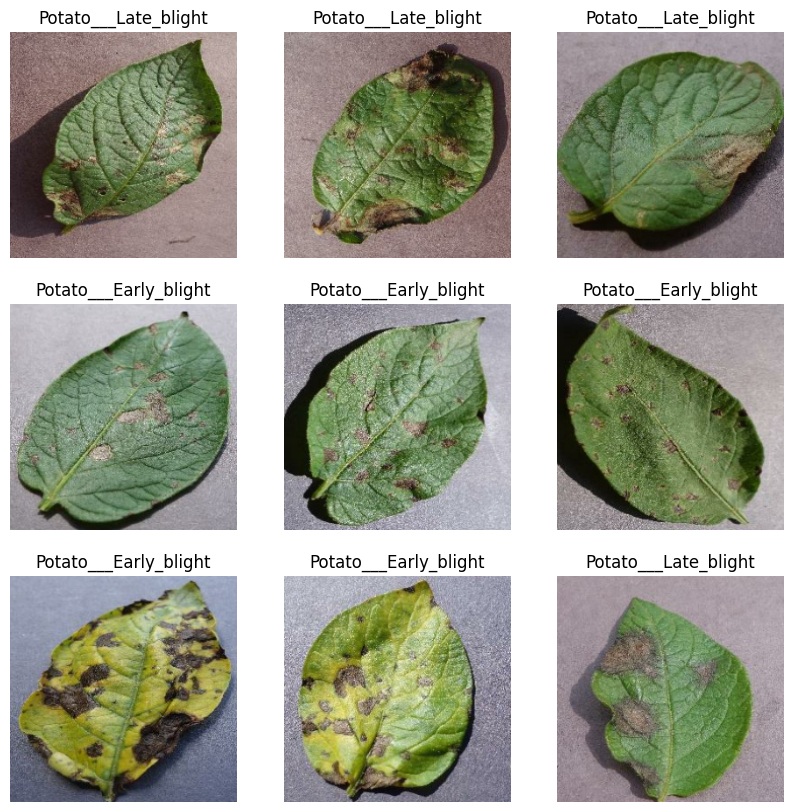

In [8]:
import matplotlib.pyplot as plt

class_names = train_raw_ds.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_raw_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i+1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_raw_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_raw_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_raw_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("خط لوله داده با موفقیت بهینه‌سازی شد.")

خط لوله داده با موفقیت بهینه‌سازی شد.


In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2)
])

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

IMG_SHAPE = (224, 224, 3)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

inputs = tf.keras.layers.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(3, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
base_learning_rate = 0.001

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

initial_epochs = 10
history = model.fit(
    train_ds,
    epochs= initial_epochs,
    validation_data=val_ds
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.8316 - loss: 0.4445 - val_accuracy: 0.9466 - val_loss: 0.1903
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9489 - loss: 0.1731 - val_accuracy: 0.9612 - val_loss: 0.1363
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9623 - loss: 0.1198 - val_accuracy: 0.9660 - val_loss: 0.1150
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9721 - loss: 0.0963 - val_accuracy: 0.9612 - val_loss: 0.1077
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9681 - loss: 0.0928 - val_accuracy: 0.9757 - val_loss: 0.0946
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9727 - loss: 0.0868 - val_accuracy: 0.9709 - val_loss: 0.0917
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9744 - loss: 0.0735 - val_accuracy: 0.9709 - val_loss: 0.0846
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9797 - loss: 0.0615 - val_accuracy: 0.9806 - 

In [12]:
base_model.trainable = True

print("تعداد کل لایه‌های بدنه MobileNetV2:", len(base_model.layers))

fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate / 10), # یعنی 0.0001
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

تعداد کل لایه‌های بدنه MobileNetV2: 154


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 1,865,283 (7.12 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [13]:
fine_tune_epochs = 10
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1, # ادامه دادن از انتهای فاز اول
    validation_data=val_ds
)

Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.9681 - loss: 0.1018 - val_accuracy: 0.9126 - val_loss: 0.1978
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.9849 - loss: 0.0402 - val_accuracy: 0.9369 - val_loss: 0.2154
Epoch 13/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9948 - loss: 0.0181 - val_accuracy: 0.9612 - val_loss: 0.0944
Epoch 14/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9971 - loss: 0.0116 - val_accuracy: 0.9903 - val_loss: 0.0267
Epoch 15/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9942 - loss: 0.0121 - val_accuracy: 0.9369 - val_loss: 0.1577
Epoch 16/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9977 - loss: 0.0099 - val_accuracy: 0.9757 - val_loss: 0.0374
Epoch 17/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.9977 - loss: 0.0065 - val_accuracy: 0.9806 - val_loss: 0.0452
Epoch 18/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.9994 - loss: 0.0043 - val_accuracy:

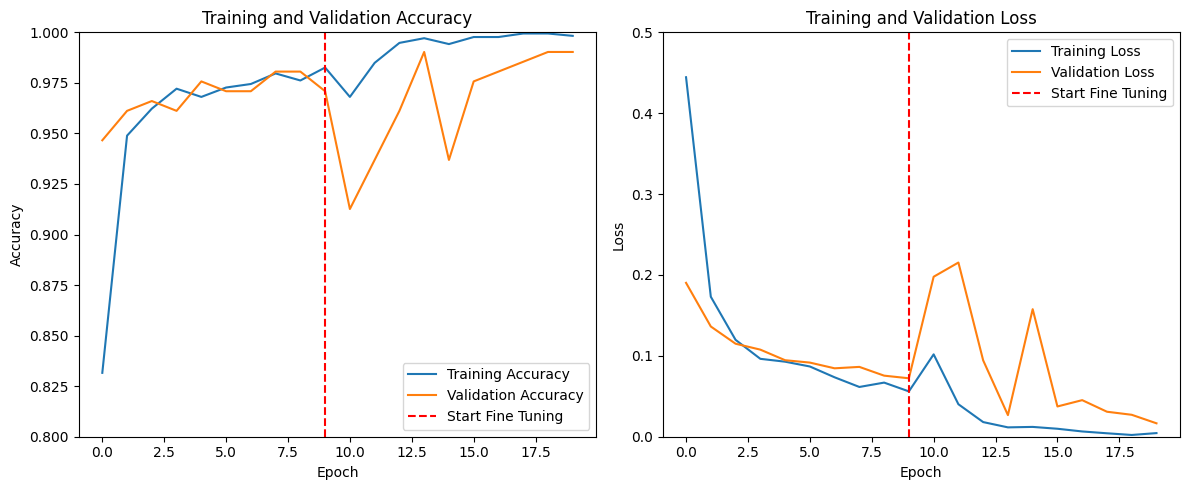

In [14]:
# ترکیب تاریخچه‌های آموزش دو فاز
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(12, 5))

# نمودار دقت (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', linestyle='--', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# نمودار خطا (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 0.5])
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', linestyle='--', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300) # ذخیره عکس با کیفیت بالا برای گیت‌هاب
plt.show()

In [15]:
print("ارزیابی روی دیتای تست (تست واقعی و نهایی):")
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nدقت نهایی روی دیتای تست: {test_accuracy * 100:.2f}%")
print(f"میزان خطای نهایی روی دیتای تست: {test_loss:.4f}")

ارزیابی روی دیتای تست (تست واقعی و نهایی):
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9866 - loss: 0.0284

دقت نهایی روی دیتای تست: 98.66%
میزان خطای نهایی روی دیتای تست: 0.0284


--- Classification Report ---
                       precision    recall  f1-score   support

Potato___Early_blight       0.98      1.00      0.99       103
 Potato___Late_blight       0.99      0.98      0.99       103
     Potato___healthy       1.00      0.94      0.97        18

             accuracy                           0.99       224
            macro avg       0.99      0.98      0.98       224
         weighted avg       0.99      0.99      0.99       224



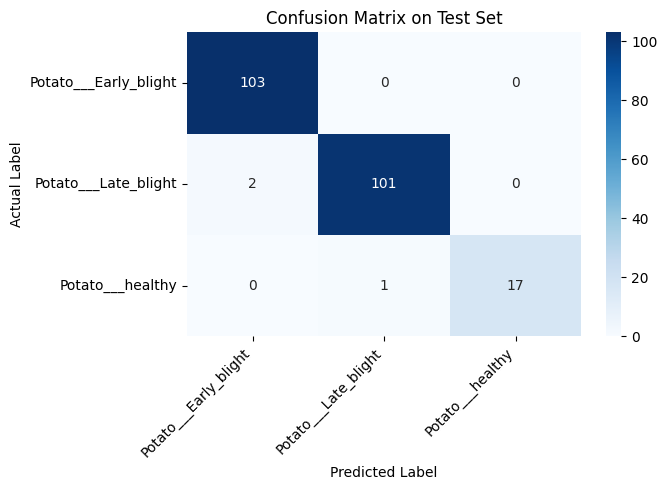


مدل نهایی با موفقیت در فایل potato_disease_mobilenetv2.keras ذخیره شد.


In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ۱. استخراج برچسب‌های واقعی و پیش‌بینی‌های مدل روی تمام دسته‌های داده تست
y_true = []
y_pred = []

for images, labels in test_ds:
    # پیش‌بینی احتمالات برای هر دسته
    preds = model.predict(images, verbose=0)
    # انتخاب کلاسی که بیشترین احتمال را دارد (argmax)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ۲. چاپ گزارش آماری کامل شامل Precision، Recall و F1-Score
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# ۳. رسم و ذخیره ماتریس درهم‌ریختگی (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300) # ذخیره تصویر برای گیت‌هاب
plt.show()

# ۴. ذخیره وزن‌ها و معماری مدل نهایی در قالب استاندارد Keras
model.save('potato_disease_mobilenetv2.keras')
print("\nمدل نهایی با موفقیت در فایل potato_disease_mobilenetv2.keras ذخیره شد.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


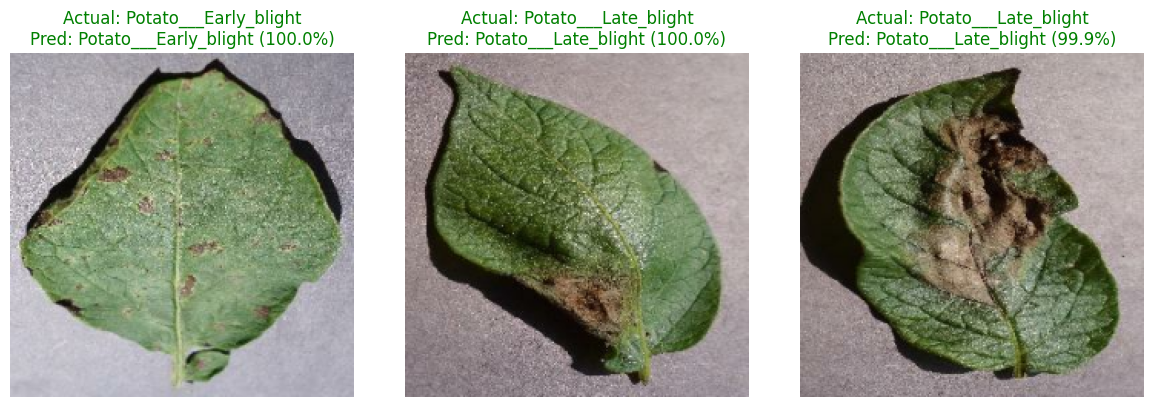

In [17]:
plt.figure(figsize=(12, 4))

# انتخاب یک دسته از داده تست و پیش‌بینی
for images, labels in test_ds.take(1):
    preds = model.predict(images)

    for i in range(3):
        ax = plt.subplot(1, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        actual_class = class_names[labels[i]]
        predicted_class = class_names[np.argmax(preds[i])]
        confidence = 100 * np.max(preds[i])

        plt.title(f"Actual: {actual_class}\nPred: {predicted_class} ({confidence:.1f}%)",
                  color="green" if actual_class == predicted_class else "red")
        plt.axis("off")

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=300)
plt.show()